<a href="https://colab.research.google.com/github/thanusree02/Natural-Language-Processing/blob/main/NLP_LAB_12_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

print("--- Step 2: Required Libraries Imported ---")

--- Step 2: Required Libraries Imported ---


Load and Explore Dataset

In [8]:

df = pd.read_csv('/content/IMDB Dataset.csv', engine='python', on_bad_lines='skip')

print(f"Dataset Shape: {df.shape}")
print(df.head())
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

print("--- Step 3: Dataset Loaded and Inspected ---")

Dataset Shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
--- Step 3: Dataset Loaded and Inspected ---


Text Preprocessing

In [9]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text) # Remove non-alphabetic chars
    text = text.lower().split()
    return " ".join(text)

df['review'] = df['review'].apply(clean_text)

# Parameters
max_words = 10000
max_len = 100

# Tokenization
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['review'])
sequences = tokenizer.texts_to_sequences(df['review'])
word_index = tokenizer.word_index

# Padding
X = pad_sequences(sequences, maxlen=max_len)

# Label Encoding (positive -> 1, negative -> 0)
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

print(f"Processed {len(X)} reviews.")
print("--- Step 4: Text Preprocessing Completed ---")

Processed 50000 reviews.
--- Step 4: Text Preprocessing Completed ---


 Vocabulary and Embedding Preparation

In [10]:
embedding_dim = 100
embeddings_index = {}

# Load GloVe file
try:
    with open('glove.6B.100d.txt', encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f"Loaded {len(embeddings_index)} word vectors.")
except FileNotFoundError:
    print("GloVe file not found! Proceeding with zero matrix for demonstration.")

# Map words to embedding vectors
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    if i < max_words:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

print("--- Step 5: Vocabulary and Embedding Matrix Prepared ---")

GloVe file not found! Proceeding with zero matrix for demonstration.
--- Step 5: Vocabulary and Embedding Matrix Prepared ---


Train–Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training: {X_train.shape}, Testing: {X_test.shape}")
print("--- Step 6: Train-Test Split Completed ---")

Training: (40000, 100), Testing: (10000, 100)
--- Step 6: Train-Test Split Completed ---


 Build 1D CNN Model with Pretrained Embeddings

In [12]:
model = Sequential([
    Embedding(max_words, embedding_dim, input_length=max_len,
              weights=[embedding_matrix], trainable=False),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(10, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

print("--- Step 7: 1D CNN Model Built ---")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

--- Step 7: 1D CNN Model Built ---


 Model Training

In [13]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)

print("--- Step 8: Model Training Completed ---")

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 34ms/step - accuracy: 0.4983 - loss: 0.6932 - val_accuracy: 0.4961 - val_loss: 0.6932
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 29ms/step - accuracy: 0.4989 - loss: 0.6932 - val_accuracy: 0.5039 - val_loss: 0.6931
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.4960 - loss: 0.6932 - val_accuracy: 0.4961 - val_loss: 0.6932
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.5012 - loss: 0.6932 - val_accuracy: 0.4961 - val_loss: 0.6932
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.5011 - loss: 0.6932 - val_accuracy: 0.4961 - val_loss: 0.6932
--- Step 8: Model Training Completed ---


Model Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

Accuracy Score: 0.4961

Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.66      4961
           1       0.00      0.00      0.00      5039

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.33     10000
weighted avg       0.25      0.50      0.33     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


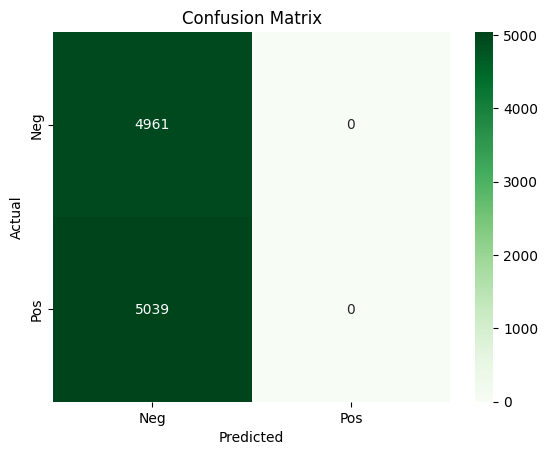

--- Step 9: Model Evaluation Completed ---


In [14]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("--- Step 9: Model Evaluation Completed ---")